In [46]:
import duckdb
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

from advan_test import data
from advan_test.utils import project_root

# config
sns.set_theme(style="ticks")
pl.Config.set_engine_affinity("streaming")

con = duckdb.connect()
con.install_extension("spatial")
con.load_extension("spatial")

In [38]:
ROOT = project_root()
DATA_PATH = ROOT / "data"
PARQUET_DIR_PATH = DATA_PATH / "2025-weekly-patterns-plus"
DATA_GLOB = PARQUET_DIR_PATH / "*.parquet"
CSV_PATH = DATA_PATH / "weekly-patterns-plus-sample.csv"
US_PATH = DATA_PATH / "us-states.json"
SHP_PATH = DATA_PATH / "tl_2025_04_bg" / "tl_2025_04_bg.shp"

In [49]:
con.execute(f"""
    CREATE OR REPLACE TABLE states AS
    SELECT * FROM ST_Read('{US_PATH}')
""")
con.execute(f"""
    CREATE OR REPLACE TABLE arizona_shp AS
    SELECT * FROM '{SHP_PATH}'
""")

In [7]:
lf = con.sql(f"""
    WITH boundary AS (
        SELECT geom
        FROM states 
        WHERE name = 'Arizona'
    ), t AS (
        SELECT *
        FROM '{DATA_GLOB}'
    )
    SELECT t.*
    FROM t, boundary
    WHERE ST_Within(
        ST_Point(t.LONGITUDE, t.LATITUDE),
        boundary.geom
    )
""").pl().lazy()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

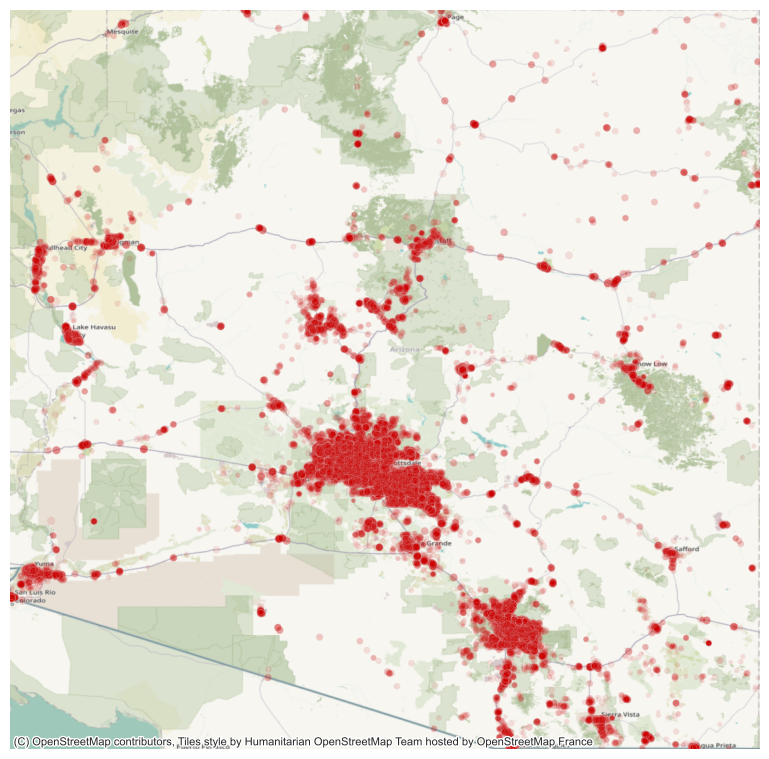

In [85]:
pois = lf.group_by("BRAND", "LONGITUDE", "LATITUDE").agg(
    pl.col("VISITOR_COUNTS").sum().cast(pl.Float64),
    pl.col("VISITOR_COUNTS").sum().log().cast(pl.Float64).alias("LOG_VISITOR_COUNTS")
).collect()
fig_scale = 2
fig, ax = plt.subplots(figsize=(6.4*fig_scale, 4.8*fig_scale))
ax = sns.scatterplot(
    pois, x="LONGITUDE", y="LATITUDE",
    color="#c00", size="LOG_VISITOR_COUNTS", sizes=(1, 50),
    alpha=.1, ax=ax, legend=False
)
ax.set_xlim(pois["LONGITUDE"].min(), pois["LONGITUDE"].max())
ax.set_ylim(pois["LATITUDE"].min(), pois["LATITUDE"].max())
cx.add_basemap(ax, crs="EPSG:4326", zoom=8)
ax.set_axis_off()
ax.set_aspect("equal")

<Axes: >

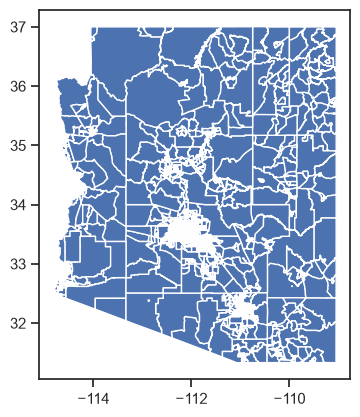

In [68]:
df = con.sql("SELECT * FROM arizona_shp").df()
df["geom"] = df["geom"].apply(bytes)
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.GeoSeries.from_wkb(df["geom"]), 
    crs="EPSG:4326"
)
gdf.plot()

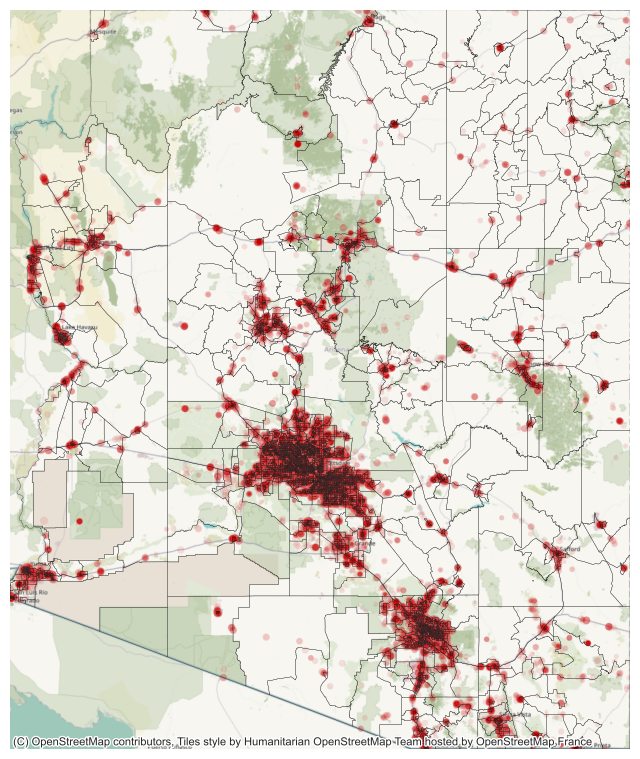

In [84]:
fig_scale = 2
fig, ax = plt.subplots(figsize=(6.4*fig_scale, 4.8*fig_scale))
gdf.boundary.plot(ax=ax, color="#222", linewidth=0.2)
ax = sns.scatterplot(
    pois, x="LONGITUDE", y="LATITUDE",
    color="#c00", size="LOG_VISITOR_COUNTS", sizes=(1, 50),
    alpha=.1, ax=ax, legend=False
)
ax.set_xlim(pois["LONGITUDE"].min(), pois["LONGITUDE"].max())
ax.set_ylim(pois["LATITUDE"].min(), pois["LATITUDE"].max())
cx.add_basemap(ax, crs="EPSG:4326", zoom=8)
ax.set_axis_off()

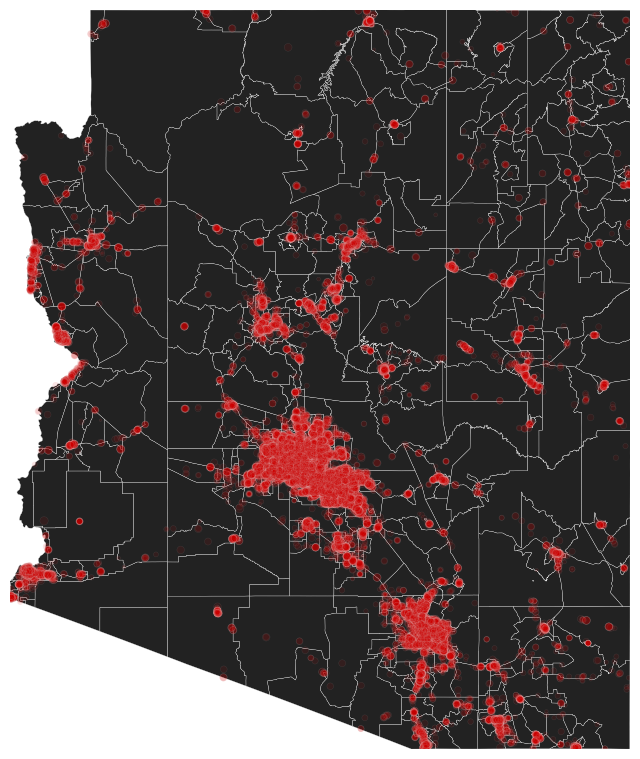

In [87]:
fig_scale = 2
fig, ax = plt.subplots(figsize=(6.4*fig_scale, 4.8*fig_scale))
gdf.plot(ax=ax, color="#222", linewidth=0.2)
ax = sns.scatterplot(
    pois, x="LONGITUDE", y="LATITUDE",
    color="#c00", size="LOG_VISITOR_COUNTS", sizes=(1, 50),
    alpha=.1, ax=ax, legend=False
)
ax.set_xlim(pois["LONGITUDE"].min(), pois["LONGITUDE"].max())
ax.set_ylim(pois["LATITUDE"].min(), pois["LATITUDE"].max())
ax.set_axis_off()